<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Clustering%20Methods%20Clustering%20to%20group%20Kenyan%20Regions%20based%20on%20soil%20and%20rainfall%20characteristics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install required packages
!pip install pyspark pandas numpy matplotlib seaborn scikit-learn jupyter

# For Hadoop (Project 2) - install on Ubuntu/WSL

In [4]:
import pandas as pd
import numpy as np

# Realistic Kenyan regional data (based on actual agro-ecological zones)
np.random.seed(42)
data = {
    'Region': [
        'Nairobi', 'Mombasa', 'Kisumu', 'Eldoret', 'Nakuru',
        'Nyeri', 'Meru', 'Machakos', 'Garissa', 'Marsabit',
        'Kitale', 'Nyandarua', 'Embu', 'Tharaka-Nithi', 'Laikipia',
        'Bungoma', 'Kakamega', 'Taita-Taveta', 'Isiolo', 'Samburu',
        'Kilifi', 'Kwale', 'Tana River', 'Turkana', 'Wajir',
        'Bomet', 'Kericho', 'Narok', 'Trans-Nzoia', 'Uasin Gishu'
    ],
    'Latitude': np.random.uniform(-4.5, 4.5, 30),
    'Longitude': np.random.uniform(33.5, 42.0, 30),
    'Altitude_m': np.random.uniform(100, 3000, 30),
    'Annual_Rainfall_mm': np.random.uniform(200, 2200, 30),
    'Soil_pH': np.random.uniform(4.5, 8.5, 30),
    'Soil_Organic_Carbon_pct': np.random.uniform(0.5, 5.0, 30),
    'Clay_Content_pct': np.random.uniform(10, 70, 30),
    'Sand_Content_pct': np.random.uniform(10, 80, 30),
    'Nitrogen_ppm': np.random.uniform(50, 500, 30),
    'Phosphorus_ppm': np.random.uniform(5, 80, 30),
    'Potassium_ppm': np.random.uniform(50, 400, 30)
}

df = pd.DataFrame(data)
df.to_csv('kenya_soil_rainfall.csv', index=False)
print("Dataset created with shape:", df.shape)
df.head()

Dataset created with shape: (30, 12)


,Region,Latitude,Longitude,Altitude_m,Annual_Rainfall_mm,Soil_pH,Soil_Organic_Carbon_pct,Clay_Content_pct,Sand_Content_pct,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm
0,Nairobi,-1.129139,38.664131,1227.164140,439.188492,7.729761,4.587196,30.463981,48.411365,473.206363,65.702087,68.088602
1,Mombasa,4.056429,34.949455,886.912192,1626.489574,8.084365,1.578029,16.808411,58.432664,479.267860,65.758505,235.974121
2,Kisumu,2.087945,34.052939,2503.338777,1721.570097,5.772014,1.152027,65.481617,55.637288,461.688976,70.030424,239.222293
3,Eldoret,0.887926,41.565527,1134.584647,1322.554395,4.940208,2.702537,62.640361,25.698852,216.571415,73.493041,273.100466
4,Nakuru,-3.095832,41.707872,914.710078,1741.934360,5.411741,4.935427,25.476498,59.852545,56.955477,43.350680,304.131967


In [5]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Spark
spark = SparkSession.builder \
    .appName("KenyaRegionalClustering") \
    .master("local[*]") \
    .getOrCreate()

# Load data into Spark DataFrame
spark_df = spark.read.csv('kenya_soil_rainfall.csv',
                          header=True, inferSchema=True)

# Check for missing values
spark_df.describe().show()

# Select features for clustering
feature_cols = ['Annual_Rainfall_mm', 'Soil_pH', 'Soil_Organic_Carbon_pct',
                'Clay_Content_pct', 'Sand_Content_pct', 'Nitrogen_ppm',
                'Phosphorus_ppm', 'Potassium_ppm', 'Altitude_m']

# Assemble features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_assembled = assembler.transform(spark_df)

# Scale features (CRITICAL for distance-based clustering)
scaler = StandardScaler(inputCol="features_raw",
                        outputCol="features",
                        withStd=True, withMean=True)
df_scaled = scaler.fit(df_assembled).transform(df_assembled)

print("Preprocessing complete. Sample of scaled data:")
df_scaled.select("Region", "features").show(5, truncate=False)

+-------+------+-------------------+------------------+------------------+------------------+-----------------+-----------------------+------------------+------------------+------------------+-----------------+------------------+
|summary|Region|           Latitude|         Longitude|        Altitude_m|Annual_Rainfall_mm|          Soil_pH|Soil_Organic_Carbon_pct|  Clay_Content_pct|  Sand_Content_pct|      Nitrogen_ppm|   Phosphorus_ppm|     Potassium_ppm|
+-------+------+-------------------+------------------+------------------+------------------+-----------------+-----------------------+------------------+------------------+------------------+-----------------+------------------+
|  count|    30|                 30|                30|                30|                30|               30|                     30|                30|                30|                30|               30|                30|
|   mean|  NULL|-0.5526245511230691| 37.71943626603952|1498.2620395967822|1182.5

K=2, WSSSE=227.54
K=3, WSSSE=205.48
K=4, WSSSE=178.72
K=5, WSSSE=152.06
K=6, WSSSE=135.88
K=7, WSSSE=137.23
K=8, WSSSE=122.81
K=9, WSSSE=113.37


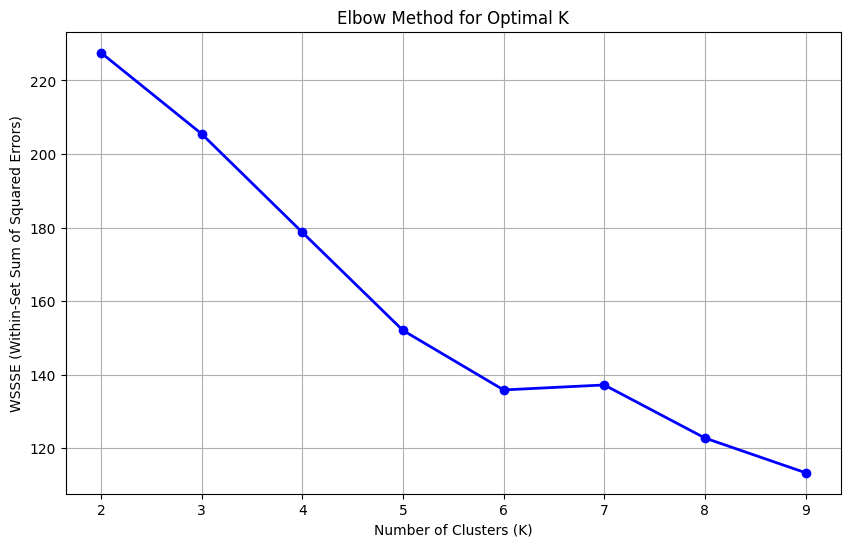

In [7]:
# Elbow method to find optimal K
wssse_values = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(featuresCol="features", k=k, seed=42, maxIter=50)
    model = kmeans.fit(df_scaled)
    wssse = model.summary.trainingCost
    wssse_values.append(wssse)
    print(f"K={k}, WSSSE={wssse:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wssse_values, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WSSSE (Within-Set Sum of Squared Errors)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Apply K-Means with optimal K (let's use K=5 based on Kenya's agro-zones)
kmeans = KMeans(featuresCol="features", k=5, seed=42, maxIter=100)
kmeans_model = kmeans.fit(df_scaled)

# Add predictions
df_kmeans = kmeans_model.transform(df_scaled)

# Evaluate
evaluator = ClusteringEvaluator(featuresCol="features")
silhouette_kmeans = evaluator.evaluate(df_kmeans)
print(f"K-Means Silhouette Score: {silhouette_kmeans:.4f}")

# Show cluster centers
centers = kmeans_model.clusterCenters()
print("\nK-Means Cluster Centers (in scaled space):")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

# Collect results for interpretation
kmeans_results = df_kmeans.select("Region", "prediction",
                                   "Annual_Rainfall_mm",
                                   "Soil_pH",
                                   "Soil_Organic_Carbon_pct").toPandas()
print("\nK-Means Cluster Assignments:")
print(kmeans_results.sort_values('prediction'))

K-Means Silhouette Score: 0.2327

K-Means Cluster Centers (in scaled space):
Cluster 0: [-0.10191057 -0.57466503 -0.49640761  1.02513295  0.04096282  0.19483578
 -0.24567126 -0.91547026 -1.1896987 ]
Cluster 1: [-0.38099508 -0.42680838 -0.14703233 -0.27629509 -0.99735484  0.05956726
 -1.40696627  0.70191808  0.39068686]
Cluster 2: [-0.48145217  0.95137175  0.44565146 -0.19883566  0.57396504  0.24134812
  0.541089   -0.41539993  0.3439299 ]
Cluster 3: [ 0.6475149  -0.02190545 -0.79184279  0.60642072 -0.63090572 -0.0296674
  0.72827322  0.88142097  0.42665978]
Cluster 4: [ 1.28047401 -0.85431381  0.64287406 -1.23258836  0.63058114 -0.95530746
  0.39796056  0.47740713 -0.08796678]

K-Means Cluster Assignments:
           Region  prediction  Annual_Rainfall_mm   Soil_pH  \
11      Nyandarua           0         1472.820823  5.388431   
12           Embu           0          828.711962  4.979461   
8         Garissa           0          250.838253  4.527809   
17   Taita-Taveta           0   

In [9]:
# Bisecting K-Means - a hierarchical divisive method
bisecting_kmeans = BisectingKMeans(featuresCol="features", k=5,
                                    maxIter=50, seed=42)
bkm_model = bisecting_kmeans.fit(df_scaled)

df_bkm = bkm_model.transform(df_scaled)
silhouette_bkm = evaluator.evaluate(df_bkm)
print(f"\nBisecting K-Means Silhouette Score: {silhouette_bkm:.4f}")

bkm_results = df_bkm.select("Region", "prediction",
                             "Annual_Rainfall_mm",
                             "Soil_pH").toPandas()
print("\nBisecting K-Means Cluster Assignments:")
print(bkm_results.sort_values('prediction'))


Bisecting K-Means Silhouette Score: 0.2375

Bisecting K-Means Cluster Assignments:
           Region  prediction  Annual_Rainfall_mm   Soil_pH
12           Embu           0          828.711962  4.979461
11      Nyandarua           0         1472.820823  5.388431
18         Isiolo           0          657.596331  5.954518
17   Taita-Taveta           0         1711.102277  7.312076
23        Turkana           0         1816.240759  5.703513
6            Meru           1         1245.465659  7.772059
3         Eldoret           1         1322.554395  4.940208
4          Nakuru           1         1741.934360  5.411741
19        Samburu           1          353.959820  8.387128
14       Laikipia           1         2015.132948  8.271639
22     Tana River           1         2059.395305  6.488994
1         Mombasa           2         1626.489574  8.084365
10         Kitale           2          262.858371  6.169644
7        Machakos           2         1055.082037  7.942922
2          Kisum

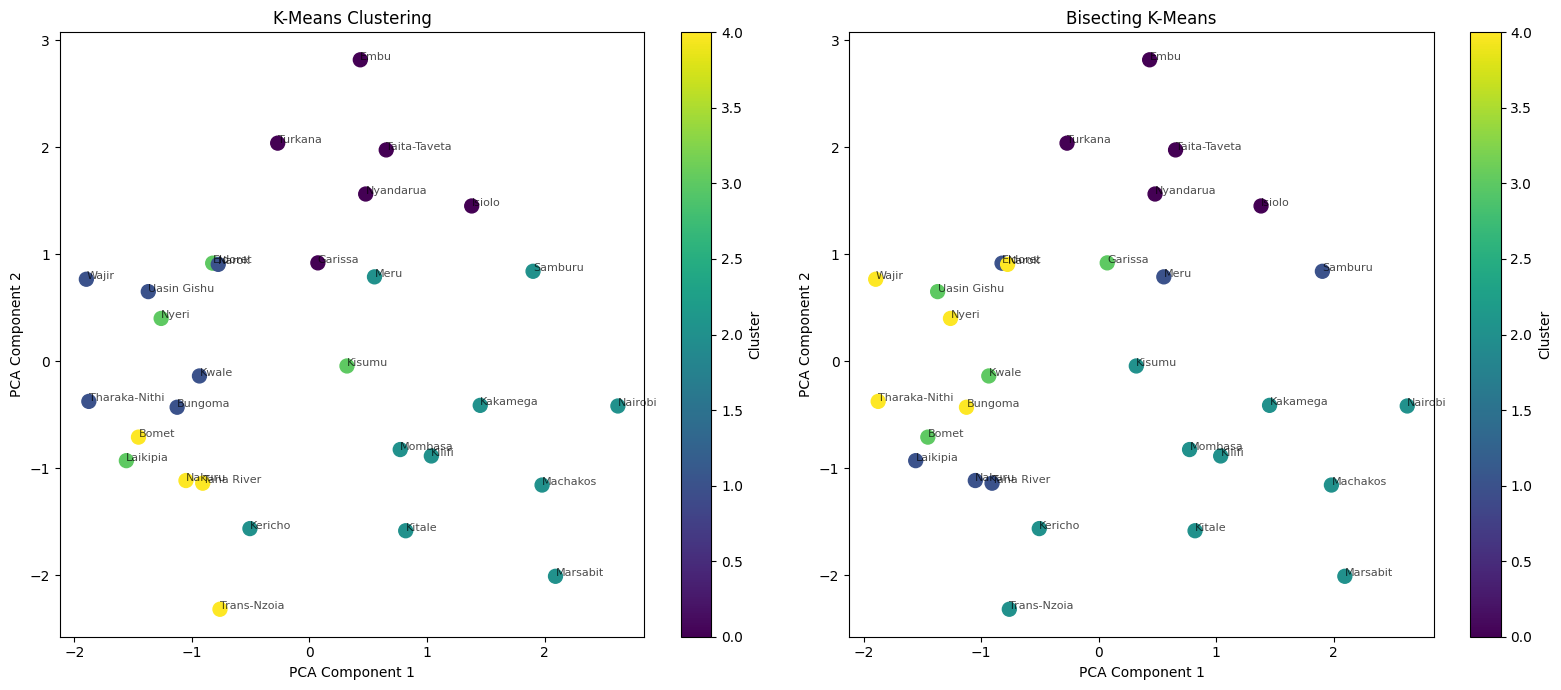

In [10]:
# Reduce to 2D using PCA for visualization
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

# Combine K-Means and Bisecting results
df_viz = df_pca.join(
    df_kmeans.select("Region", "prediction").withColumnRenamed("prediction", "kmeans_cluster"),
    on="Region"
).join(
    df_bkm.select("Region", "prediction").withColumnRenamed("prediction", "bkm_cluster"),
    on="Region"
).toPandas()

# Extract PCA coordinates
df_viz['pca_x'] = df_viz['pca_features'].apply(lambda x: x[0])
df_viz['pca_y'] = df_viz['pca_features'].apply(lambda x: x[1])

# Plot both clusterings side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cluster_col, title in zip(axes,
                                   ['kmeans_cluster', 'bkm_cluster'],
                                   ['K-Means Clustering', 'Bisecting K-Means']):
    scatter = ax.scatter(df_viz['pca_x'], df_viz['pca_y'],
                         c=df_viz[cluster_col], cmap='viridis', s=100)
    for i, row in df_viz.iterrows():
        ax.annotate(row['Region'], (row['pca_x'], row['pca_y']),
                   fontsize=8, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Detailed cluster analysis
cluster_summary = df_kmeans.toPandas().groupby('prediction').agg({
    'Annual_Rainfall_mm': 'mean',
    'Soil_pH': 'mean',
    'Soil_Organic_Carbon_pct': 'mean',
    'Nitrogen_ppm': 'mean',
    'Phosphorus_ppm': 'mean',
    'Region': lambda x: ', '.join(x)
}).round(2)

print("\n=== CLUSTER PROFILES & AGRICULTURAL RECOMMENDATIONS ===\n")

recommendations = {
    0: "HIGH-RAINFALL ACIDIC SOILS → Tea, coffee, macadamia. Apply lime to correct pH. Intercrop with legumes for nitrogen fixation.",
    1: "SEMI-ARID SANDY SOILS → Drought-resistant sorghum, millet, cowpeas. Implement water harvesting, drip irrigation, and mulching.",
    2: "MODERATE RAINFALL FERTILE SOILS → Maize, beans, vegetables. Practice crop rotation, apply balanced NPK fertilizers.",
    3: "HIGH-ALTITUDE COOL ZONES → Pyrethrum, wheat, dairy pasture. Soil conservation terraces, organic manure application.",
    4: "LOW RAINFALL PASTORAL ZONES → Livestock rearing, drought-tolerant forage (Brachiaria). Range management, water pans."
}

for cluster_id in cluster_summary.index:
    print(f"--- CLUSTER {cluster_id} ---")
    print(f"Regions: {cluster_summary.loc[cluster_id, 'Region']}")
    print(f"Avg Rainfall: {cluster_summary.loc[cluster_id, 'Annual_Rainfall_mm']} mm")
    print(f"Avg Soil pH: {cluster_summary.loc[cluster_id, 'Soil_pH']}")
    print(f"Avg Organic C: {cluster_summary.loc[cluster_id, 'Soil_Organic_Carbon_pct']}%")
    print(f"RECOMMENDATION: {recommendations.get(cluster_id, 'Mixed farming systems')}")
    print()


=== CLUSTER PROFILES & AGRICULTURAL RECOMMENDATIONS ===

--- CLUSTER 0 ---
Regions: Garissa, Nyandarua, Embu, Taita-Taveta, Isiolo, Turkana
Avg Rainfall: 1122.89 mm
Avg Soil pH: 5.64
Avg Organic C: 1.97%
RECOMMENDATION: HIGH-RAINFALL ACIDIC SOILS → Tea, coffee, macadamia. Apply lime to correct pH. Intercrop with legumes for nitrogen fixation.

--- CLUSTER 1 ---
Regions: Tharaka-Nithi, Bungoma, Kwale, Wajir, Narok, Uasin Gishu
Avg Rainfall: 959.47 mm
Avg Soil pH: 5.82
Avg Organic C: 2.42%
RECOMMENDATION: SEMI-ARID SANDY SOILS → Drought-resistant sorghum, millet, cowpeas. Implement water harvesting, drip irrigation, and mulching.

--- CLUSTER 2 ---
Regions: Nairobi, Mombasa, Meru, Machakos, Marsabit, Kitale, Kakamega, Samburu, Kilifi, Kericho
Avg Rainfall: 900.64 mm
Avg Soil pH: 7.45
Avg Organic C: 3.18%
RECOMMENDATION: MODERATE RAINFALL FERTILE SOILS → Maize, beans, vegetables. Practice crop rotation, apply balanced NPK fertilizers.

--- CLUSTER 3 ---
Regions: Kisumu, Eldoret, Nyeri, L